# Phase 2: TF-IDF + LSA + K-Means topic clustering

This notebook starts from `reviews_with_sentiment.csv`, generated at the end of Phase 1.

The reusable clustering pipeline is implemented in `src/clustering/tfidf_kmeans.py`:

1. TF-IDF text features
2. TruncatedSVD for Latent Semantic Analysis
3. L2 normalization
4. K-Means clustering

The notebook is responsible only for orchestration, reporting, manual interpretation, and saving outputs.


In [ ]:
# locate the project root
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/karima/Ironhack-challenges/voxforge-ai-review-analytics


In [19]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data.load import load_csv
from src.clustering.tfidf_kmeans import (
    add_topic_labels,
    cluster_size_summary,
    create_svd_coordinates,
    evaluate_cluster_counts,
    fit_topic_model,
    representative_reviews,
    save_topic_model,
    top_terms,
    topic_sentiment_summary,
)

from src.config import (
    CLUSTERED_REVIEWS_PATH,
    CLUSTERING_MODELS_DIR,
    CLUSTERING_RESULTS_DIR,
    ENRICHED_REVIEWS_PATH,
    DEFAULT_CLUSTER_COUNTS,
    SVD_COMPONENTS,
    DEFAULT_N_CLUSTERS,
    create_project_directories,
)

create_project_directories()

TEXT_COLUMN = "classical_text"
MODEL_FILENAME = "tfidf_svd_kmeans.joblib"


## Load the enriched review data

All input and output paths continue to come from `src/config.py`.


In [15]:
from pathlib import Path

for base in [
    Path("/content/voxforge-ai-review-analytics"),
    Path.cwd(),
    Path("/Users/karima/Ironhack-challenges/voxforge-ai-review-analytics"),
]:
    matches = list(base.rglob("reviews_with_sentiment.csv"))
    if matches:
        print("FOUND:", matches[0])
        break
else:
    print("No reviews_with_sentiment.csv found.")

FOUND: /Users/karima/Ironhack-challenges/voxforge-ai-review-analytics/data/processed/reviews_with_sentiment.csv


In [16]:
reviews = load_csv(ENRICHED_REVIEWS_PATH)

if TEXT_COLUMN not in reviews.columns:
    raise KeyError(
        f"Missing clustering text column: {TEXT_COLUMN!r}. "
        f"Available columns: {list(reviews.columns)}"
    )

model_data = reviews.dropna(subset=[TEXT_COLUMN]).copy()
model_data[TEXT_COLUMN] = model_data[TEXT_COLUMN].astype(str).str.strip()
model_data = (
    model_data[model_data[TEXT_COLUMN].str.len().gt(0)]
    .reset_index(drop=True)
)

print(f"Rows available for clustering: {len(model_data):,}")


INFO - Loaded 47279 rows


Rows available for clustering: 47,276


## 1. Compare a small range of cluster counts

Silhouette and inertia are diagnostic signals, not automatic selectors. The final value of K is also judged through top terms, representative reviews, cluster sizes, and business interpretability.


,n_clusters,inertia,silhouette_score,svd_components,svd_explained_variance_ratio
0,2,42057.972656,0.032753,100,0.209781
1,3,40951.210938,0.033262,100,0.209781
2,4,40097.500000,0.039695,100,0.209781
3,5,39312.824219,0.046156,100,0.209781
4,6,38625.796875,0.051451,100,0.209781
5,7,37987.539062,0.052092,100,0.209781
6,8,37501.109375,0.053756,100,0.209781
7,9,36965.207031,0.056712,100,0.209781
8,10,36516.867188,0.059475,100,0.209781


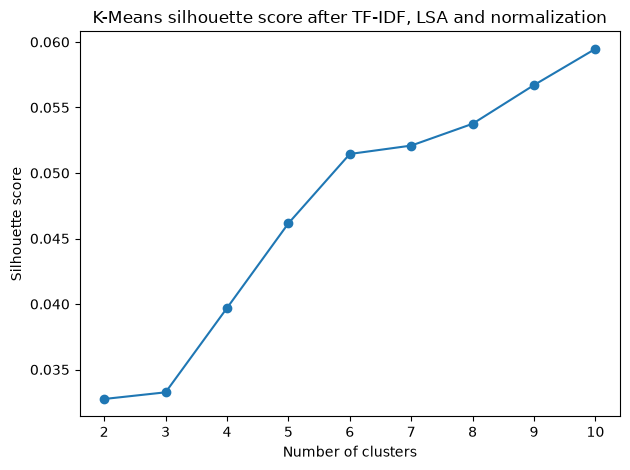

In [17]:
cluster_scores = evaluate_cluster_counts(
    model_data[TEXT_COLUMN],
    cluster_counts=DEFAULT_CLUSTER_COUNTS,
    svd_components=SVD_COMPONENTS,
)

cluster_scores.to_csv(
    CLUSTERING_RESULTS_DIR / "cluster_count_evaluation.csv",
    index=False,
)

display(cluster_scores)

ax = cluster_scores.plot(
    x="n_clusters",
    y="silhouette_score",
    marker="o",
    legend=False,
)
ax.set_title("K-Means silhouette score after TF-IDF, LSA and normalization")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()


## 2. Fit the selected cluster count

The scores are interpreted alongside qualitative cluster evidence. If the curve remains low and flat, the selected K is justified primarily by interpretability rather than by a decisive metric optimum.


In [20]:
N_CLUSTERS = DEFAULT_N_CLUSTERS

run = fit_topic_model(
    model_data[TEXT_COLUMN],
    n_clusters=N_CLUSTERS,
    svd_components=SVD_COMPONENTS,
)

print(f"Final silhouette score: {run['silhouette_score']:.4f}")
print(
    "SVD explained variance ratio: "
    f"{run['explained_variance_ratio']:.4f}"
)

terms = top_terms(run, top_n=12)
representatives = representative_reviews(
    model_data[TEXT_COLUMN],
    run,
    reviews_per_cluster=5,
)
cluster_sizes = cluster_size_summary(run)

terms.to_csv(
    CLUSTERING_RESULTS_DIR / "top_terms.csv",
    index=False,
)
representatives.to_csv(
    CLUSTERING_RESULTS_DIR / "representative_reviews.csv",
    index=False,
)
cluster_sizes.to_csv(
    CLUSTERING_RESULTS_DIR / "cluster_sizes.csv",
    index=False,
)

display(
    terms.groupby("cluster_id")["term"]
    .apply(list)
    .to_frame(name="top_terms")
)
display(representatives)
display(cluster_sizes)


Final silhouette score: 0.0515
SVD explained variance ratio: 0.2098


,top_terms
cluster_id,
0,"[great, good, work, love, price, tv, use, easy..."
1,"[tablet, great tablet, great, price, kid, good..."
2,"[kindle, book, read, reading, reader, love, gr..."
3,"[battery, good, brand, price, long, great, gre..."
4,"[echo, alexa, music, love, fun, home, great, s..."
5,"[product, great product, great, good product, ..."


,cluster_id,rank,review_index,review_text,distance_to_centroid
0,0,1,3174,five star excelente,0.276577
1,0,2,37220,facemask facemask,0.276577
2,0,3,37392,five star asdfghj,0.276577
3,0,4,37499,five star buen producto,0.276577
4,0,5,37500,five star buenos productos,0.276577
5,1,1,15768,great tablet goog tablet bad part creating pro...,0.682691
6,1,2,7684,great tablet excelente producto slow price rec...,0.690657
7,1,3,3768,great tablet drop gb card beast tablet especia...,0.693098
8,1,4,12279,great tablet wonderful inexpensive tablet novi...,0.696542
9,1,5,46563,great tablet go wrong tablet no issue reliable...,0.696657


,cluster_id,review_count,percentage
0,0,17187,36.35
1,1,9004,19.05
2,2,5519,11.67
3,3,5573,11.79
4,4,5631,11.91
5,5,4362,9.23


## 3. Assign human-readable topic names

Cluster IDs are arbitrary and can change after retraining. Inspect the newly generated top terms and representative reviews before finalizing this mapping.

The initial names below reflect the previous run and must be checked against the new outputs.


In [21]:
TOPIC_NAMES = {
    0: "Kindle, Fire TV & General Product Praise",
    1: "Rating-Only Reviews",
    2: "Fire Tablets",
    3: "Echo & Alexa Devices",
    4: "Ease of Use",
    5: "Batteries",
}

expected_ids = set(range(N_CLUSTERS))
provided_ids = set(TOPIC_NAMES)

if provided_ids != expected_ids:
    raise ValueError(
        "TOPIC_NAMES must contain exactly one name for every cluster. "
        f"Expected {sorted(expected_ids)}, received {sorted(provided_ids)}."
    )

clustered = add_topic_labels(
    model_data,
    run,
    TOPIC_NAMES,
)

clustered.to_csv(
    CLUSTERED_REVIEWS_PATH,
    index=False,
)

summary = topic_sentiment_summary(clustered)
summary.to_csv(
    CLUSTERING_RESULTS_DIR / "topic_sentiment_summary.csv",
    index=False,
)

display(summary)


,topic_name,sentiment_label,review_count,topic_review_count,sentiment_percentage
0,Batteries,positive,4181,4362,95.85
1,Batteries,neutral,106,4362,2.43
2,Batteries,negative,75,4362,1.72
3,Ease of Use,positive,5358,5631,95.15
4,Ease of Use,neutral,189,5631,3.36
5,Ease of Use,negative,84,5631,1.49
6,Echo & Alexa Devices,positive,4608,5573,82.68
7,Echo & Alexa Devices,negative,683,5573,12.26
8,Echo & Alexa Devices,neutral,282,5573,5.06
9,Fire Tablets,positive,5234,5519,94.84


## 4. Two-dimensional visualization

This projection is used only for visualization. It does not retrain or change the final clusters.


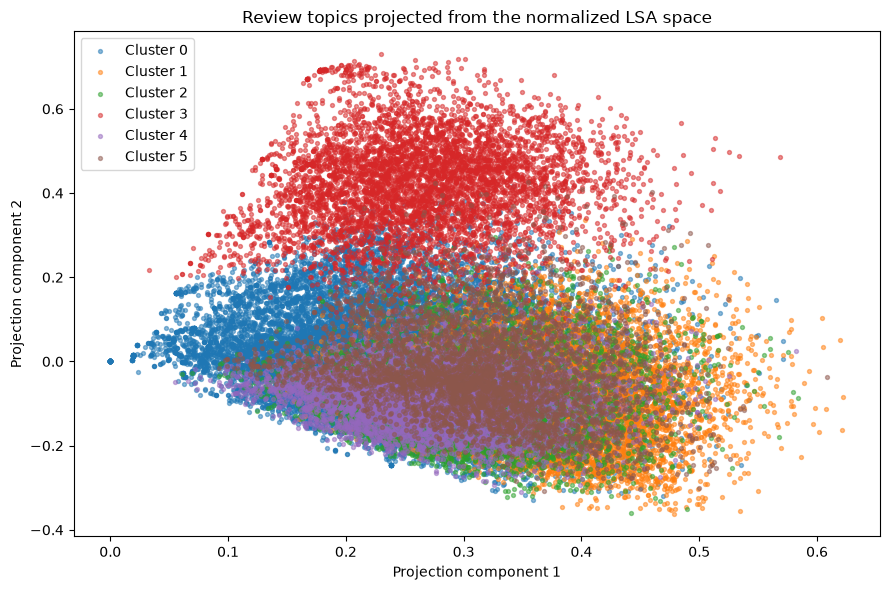

In [22]:
coordinates = create_svd_coordinates(run)

coordinates.to_csv(
    CLUSTERING_RESULTS_DIR / "svd_coordinates.csv",
    index=False,
)

plt.figure(figsize=(9, 6))

for cluster_id, group in coordinates.groupby("cluster_id"):
    plt.scatter(
        group["component_1"],
        group["component_2"],
        s=8,
        alpha=0.5,
        label=f"Cluster {cluster_id}",
    )

plt.title("Review topics projected from the normalized LSA space")
plt.xlabel("Projection component 1")
plt.ylabel("Projection component 2")
plt.legend()
plt.tight_layout()

plt.savefig(
    CLUSTERING_RESULTS_DIR / "topic_clusters_svd.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## 5. Save the reusable topic model

The artifact contains the fitted TF-IDF vectorizer, SVD transformer, normalizer, K-Means model, topic names, and compact metadata. Training matrices are intentionally excluded.


In [23]:
model_path = save_topic_model(
    run,
    CLUSTERING_MODELS_DIR / MODEL_FILENAME,
    topic_names=TOPIC_NAMES,
)

print("Saved clustered reviews:", CLUSTERED_REVIEWS_PATH)
print("Saved topic model:", model_path)


Saved clustered reviews: /Users/karima/Ironhack-challenges/voxforge-ai-review-analytics/data/processed/reviews_with_sentiment_and_topics.csv
Saved topic model: /Users/karima/Ironhack-challenges/voxforge-ai-review-analytics/models/clustering/tfidf_svd_kmeans.joblib


## Key learning from the first implementation of clustering

- We evaluated several values of K using the Elbow Method. K=5 provided a good trade-off between cluster separation and interpretability. The resulting clusters corresponded to meaningful customer-review themes.
- silhouette thresholds such as 0.5 = strong are only rough rules. Text datasets with short, sparse reviews frequently produce much lower values than conventional tabular clustering datasets.

k=8 scoring 0.0094
k=6 scoring close to 0.009
k=2 scoring 0.0067

Silhouette scores remained very low and relatively flat across the tested values of K, indicating substantial overlap between review clusters. Six clusters were therefore selected primarily for interpretability and their ability to reveal recognizable product-related themes rather than because of a decisive quantitative optimum.
- Correct real defect: rating-word leakage. The current preprocessing removes ordinary English stop words, but terms such as:
star
stars
five
four
three
two
one
remain in the corpus. Because many review bodies contain rating phrases, KMeans treats them as meaningful topic signals ===> We should remove those as custom stopwords
- The proposed improved pipeline is:

                Review text
                    ↓
                TF-IDF
                    ↓
                TruncatedSVD, approximately 100 dimensions
                    ↓
                L2 normalization
                    ↓
                KMeans
    The normalization is important because after L2 normalization, Euclidean distance becomes closely related to cosine similarity.